#PCA

Task 1: Exploratory Data Analysis (EDA):

1.	Load the dataset and perform basic data exploration.

2.	Examine the distribution of features using histograms, box plots, or density plots.

3.	Investigate correlations between features to understand relationships within the data.


In [1]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler

# PCA
from sklearn.decomposition import PCA

# Clustering
from sklearn.cluster import KMeans

# Evaluation Metrics
from sklearn.metrics import silhouette_score, davies_bouldin_score

In [2]:
# Load dataset
df = pd.read_csv("wine.csv")

# Display first 5 rows

print(df.head())

   Type  Alcohol  Malic   Ash  Alcalinity  Magnesium  Phenols  Flavanoids  \
0     1    14.23   1.71  2.43        15.6        127     2.80        3.06   
1     1    13.20   1.78  2.14        11.2        100     2.65        2.76   
2     1    13.16   2.36  2.67        18.6        101     2.80        3.24   
3     1    14.37   1.95  2.50        16.8        113     3.85        3.49   
4     1    13.24   2.59  2.87        21.0        118     2.80        2.69   

   Nonflavanoids  Proanthocyanins  Color   Hue  Dilution  Proline  
0           0.28             2.29   5.64  1.04      3.92     1065  
1           0.26             1.28   4.38  1.05      3.40     1050  
2           0.30             2.81   5.68  1.03      3.17     1185  
3           0.24             2.18   7.80  0.86      3.45     1480  
4           0.39             1.82   4.32  1.04      2.93      735  


In [3]:
# Shape of dataset
print("Shape of Dataset:", df.shape)


Shape of Dataset: (178, 14)


In [4]:
# Dataset information
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Type             178 non-null    int64  
 1   Alcohol          178 non-null    float64
 2   Malic            178 non-null    float64
 3   Ash              178 non-null    float64
 4   Alcalinity       178 non-null    float64
 5   Magnesium        178 non-null    int64  
 6   Phenols          178 non-null    float64
 7   Flavanoids       178 non-null    float64
 8   Nonflavanoids    178 non-null    float64
 9   Proanthocyanins  178 non-null    float64
 10  Color            178 non-null    float64
 11  Hue              178 non-null    float64
 12  Dilution         178 non-null    float64
 13  Proline          178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB
None


In [5]:
# Statistical summary
print(df.describe())


             Type     Alcohol       Malic         Ash  Alcalinity   Magnesium  \
count  178.000000  178.000000  178.000000  178.000000  178.000000  178.000000   
mean     1.938202   13.000618    2.336348    2.366517   19.494944   99.741573   
std      0.775035    0.811827    1.117146    0.274344    3.339564   14.282484   
min      1.000000   11.030000    0.740000    1.360000   10.600000   70.000000   
25%      1.000000   12.362500    1.602500    2.210000   17.200000   88.000000   
50%      2.000000   13.050000    1.865000    2.360000   19.500000   98.000000   
75%      3.000000   13.677500    3.082500    2.557500   21.500000  107.000000   
max      3.000000   14.830000    5.800000    3.230000   30.000000  162.000000   

          Phenols  Flavanoids  Nonflavanoids  Proanthocyanins       Color  \
count  178.000000  178.000000     178.000000       178.000000  178.000000   
mean     2.295112    2.029270       0.361854         1.590899    5.058090   
std      0.625851    0.998859       0.1

In [6]:
# Check missing values
print(df.isnull().sum())


Type               0
Alcohol            0
Malic              0
Ash                0
Alcalinity         0
Magnesium          0
Phenols            0
Flavanoids         0
Nonflavanoids      0
Proanthocyanins    0
Color              0
Hue                0
Dilution           0
Proline            0
dtype: int64


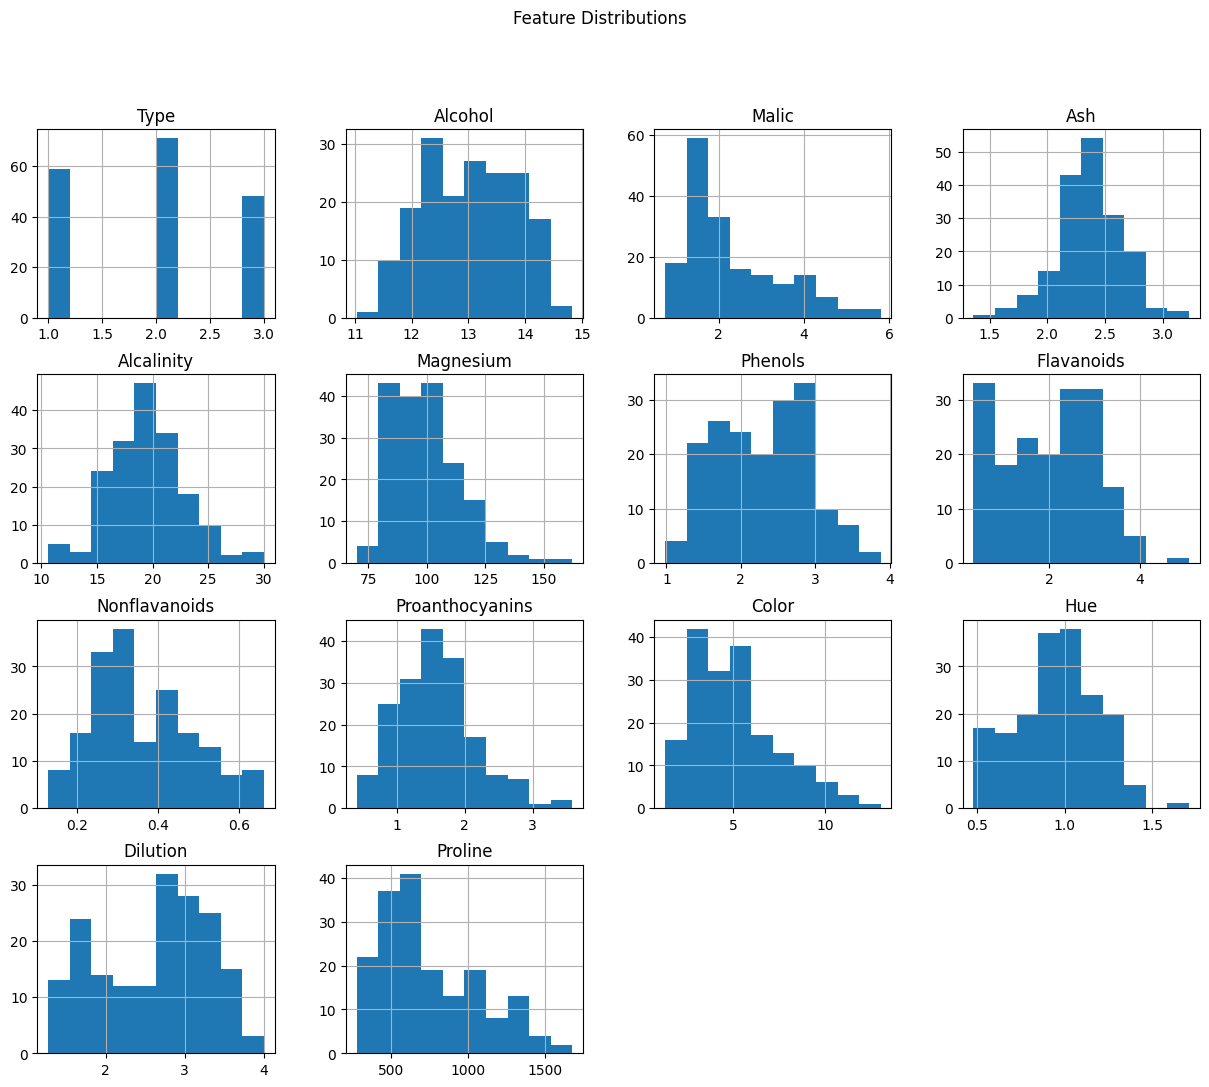

In [7]:
#Histograms
df.hist(figsize=(15,12))
plt.suptitle("Feature Distributions")
plt.show()


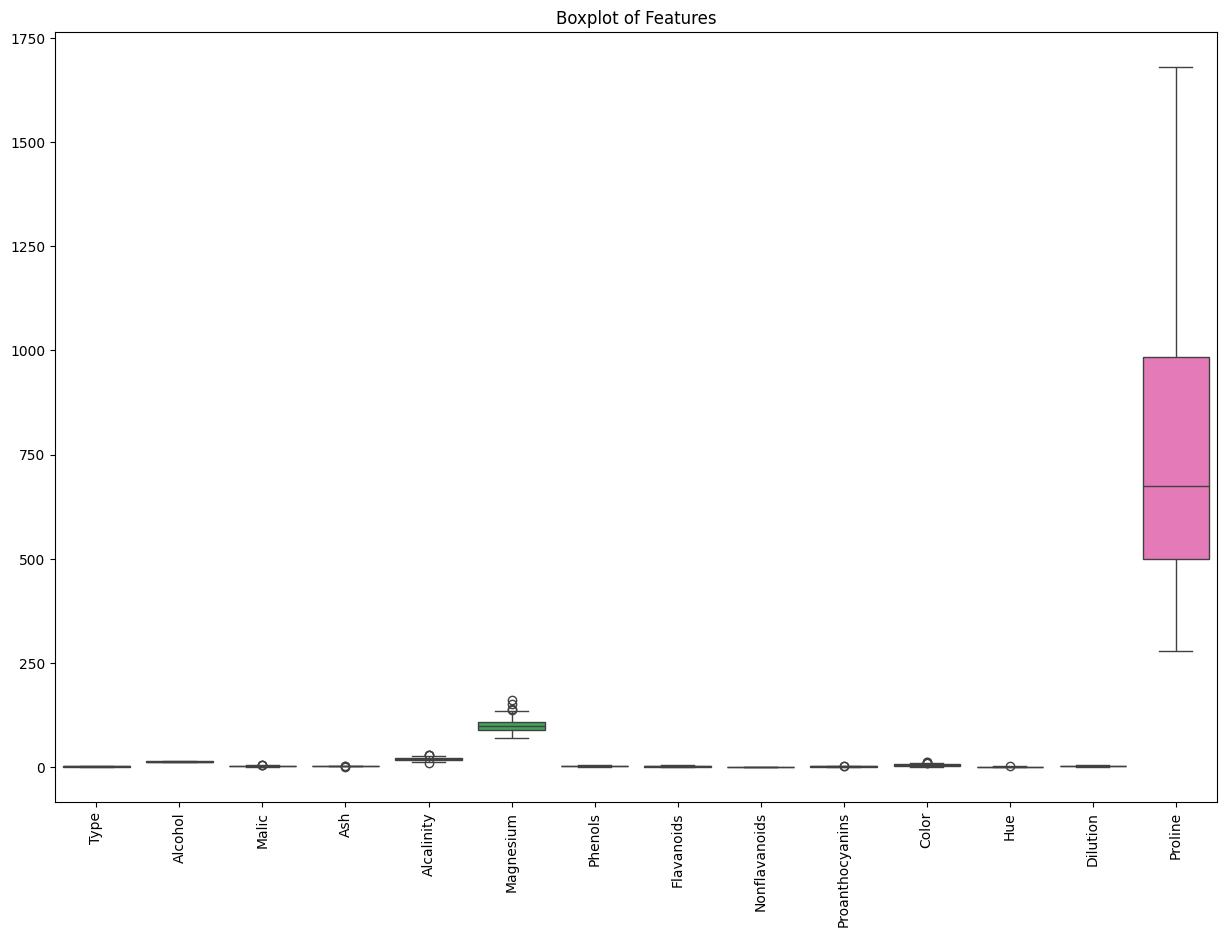

In [8]:
#Boxplots
plt.figure(figsize=(15,10))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.title("Boxplot of Features")
plt.show()


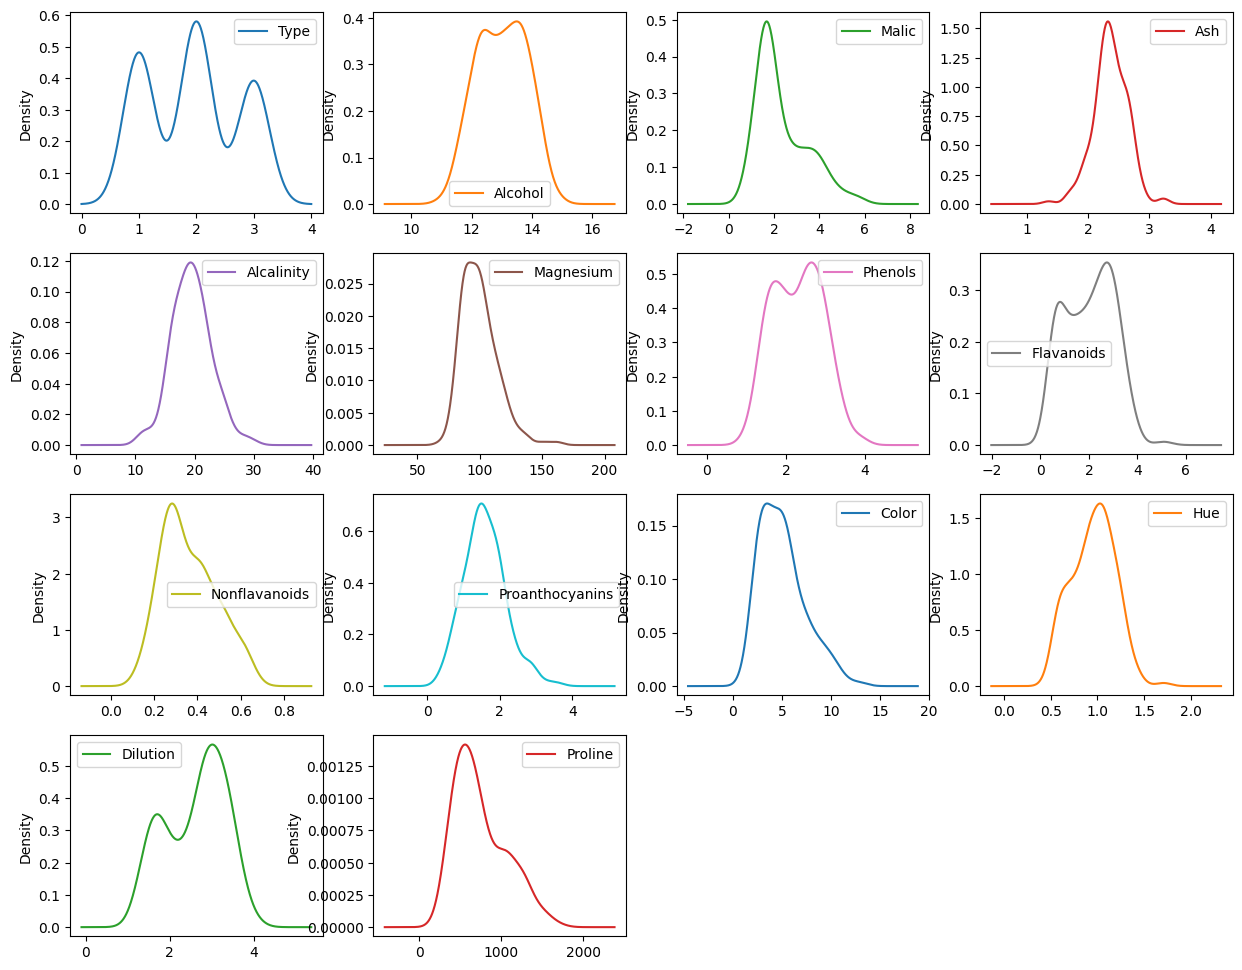

In [9]:
#Density Plots
df.plot(kind='density', subplots=True, layout=(4,4), figsize=(15,12), sharex=False)
plt.show()


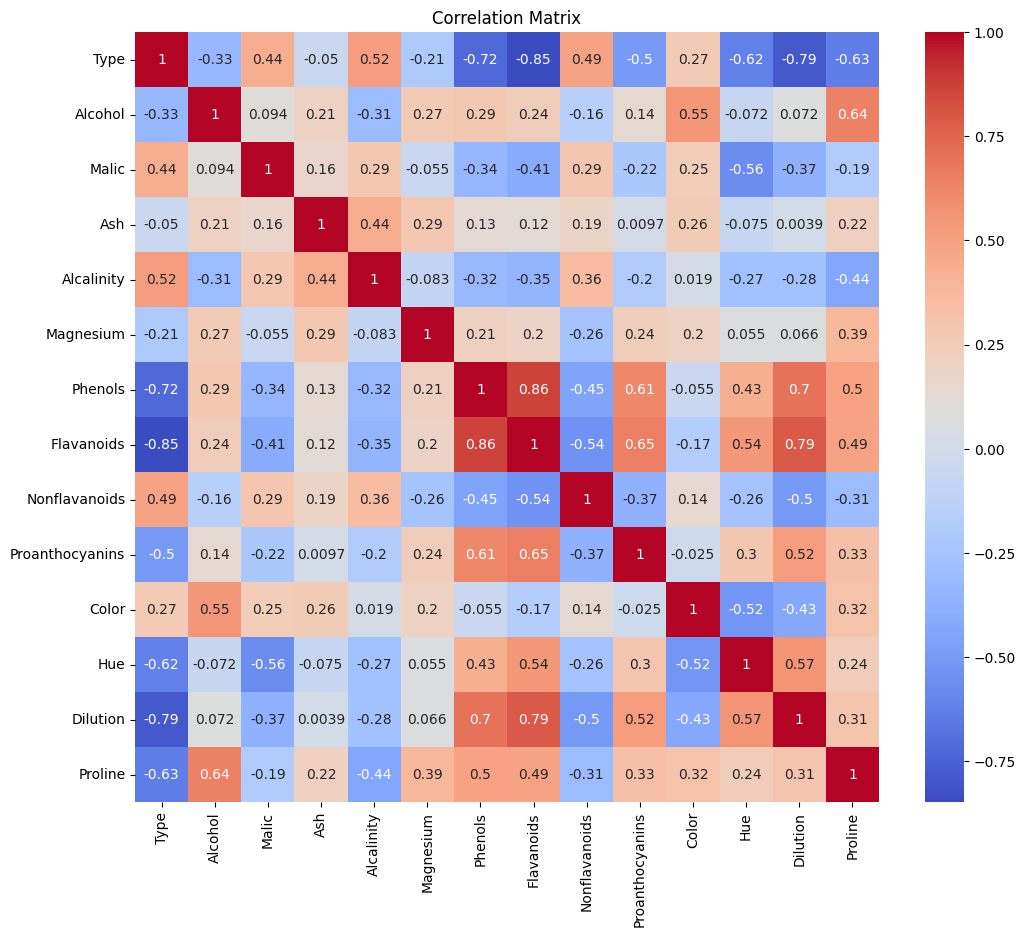

In [10]:
# Correlation Analysis
plt.figure(figsize=(12,10))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()


Task 2: Dimensionality Reduction with PCA:

1.	Standardize the features to ensure they have a mean of 0 and a standard deviation of Implement PCA to reduce the dimensionality of the dataset.

2.	Determine the optimal number of principal components using techniques like scree plot or cumulative explained variance.

3.	Transform the original dataset into the principal components.


In [11]:
# Standardize the Data
Scaler = StandardScaler()
Scaled_data = Scaler.fit_transform(df)

In [12]:
Scaled_data.shape

(178, 14)

In [13]:
# Apply PCA
pca = PCA()
pca.fit(Scaled_data)

PCA()

In [14]:
# Explained Variance Ratio
explained_variance = pca.explained_variance_ratio_

print(explained_variance)

[0.39542486 0.17836259 0.10329102 0.06627984 0.06267875 0.0480556
 0.03955707 0.02500244 0.02103871 0.01873615 0.01613203 0.01205691
 0.00925458 0.00412945]


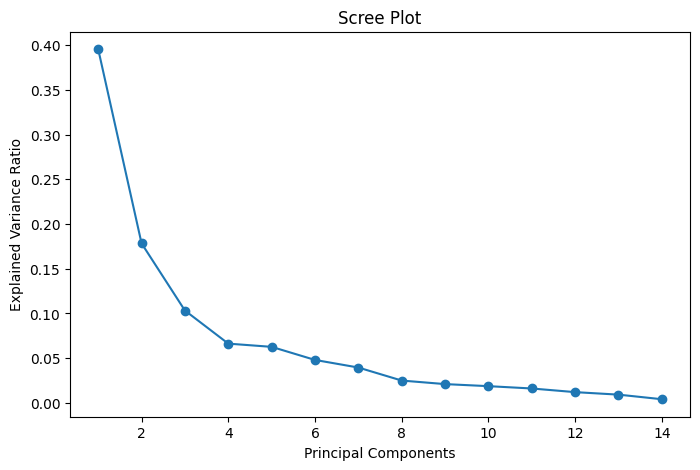

In [15]:
#Scree Plot
plt.figure(figsize=(8,5))

plt.plot(range(1, len(explained_variance)+1), explained_variance, marker='o')

plt.xlabel("Principal Components")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot")
plt.show()

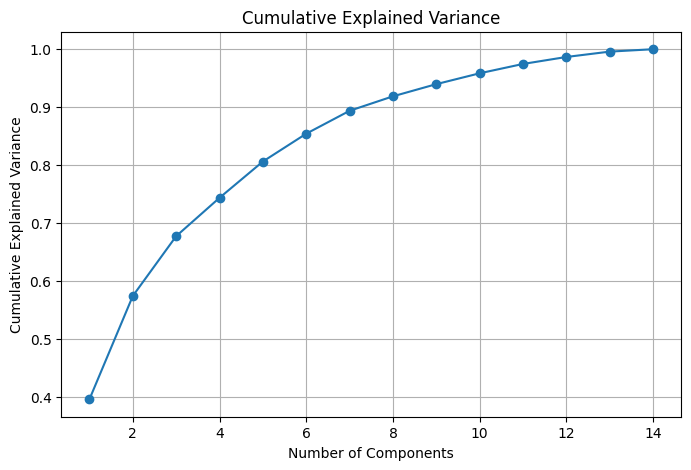

In [16]:
#Cumulative Explained Variance
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(8,5))

plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o')

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")
plt.grid()
plt.show()

In [17]:
#transform data
pca = PCA(n_components=3)
X_pca = pca.fit_transform(Scaled_data)

In [18]:
X_pca.shape

(178, 3)

Task 3: Clustering with Original Data:

1.	Apply a clustering algorithm (e.g., K-means) to the original dataset.

2.	Visualize the clustering results using appropriate plots.

3.	Evaluate the clustering performance using metrics such as silhouette score or Davies–Bouldin index.


In [19]:
# Apply K-Means Clustering

kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(Scaled_data)


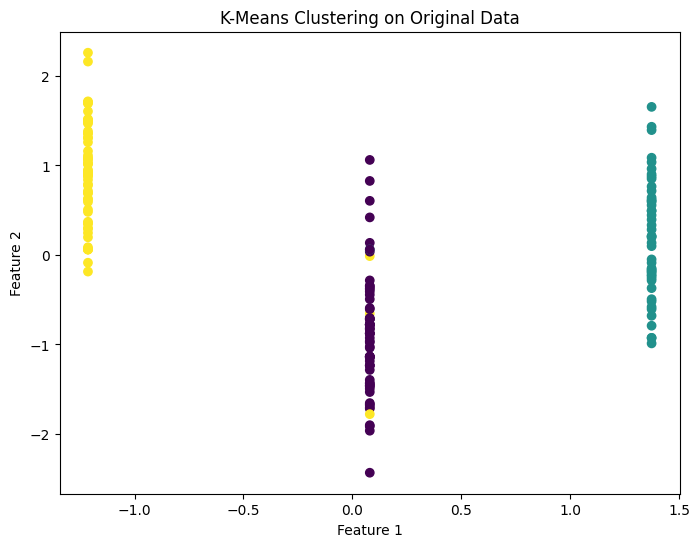

In [20]:
# Visualize Clustering Results
plt.figure(figsize=(8,6))

plt.scatter(Scaled_data[:,0], Scaled_data[:,1], c=labels, cmap='viridis')

plt.title("K-Means Clustering on Original Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


In [21]:
# Evaluate Clustering Performance
#Silhouette Score

silhouette_original = silhouette_score(Scaled_data, labels)

print("Silhouette Score (Original Data):", silhouette_original)


Silhouette Score (Original Data): 0.30648398324833453


In [22]:
#Davies-Bouldin Index
db_original = davies_bouldin_score(Scaled_data, labels)

print("Davies-Bouldin Index (Original Data):", db_original)


Davies-Bouldin Index (Original Data): 1.315707552261773


Task 4: Clustering with PCA Data:

1.	Apply the same clustering algorithm to the PCA-transformed dataset.

2.	Visualize the clustering results obtained from PCA-transformed data.

3.	Compare the clustering results from PCA-transformed data with those from the original dataset.


In [23]:
kmeans_pca = KMeans(n_clusters=3, random_state=42)
labels_pca = kmeans_pca.fit_predict(X_pca)

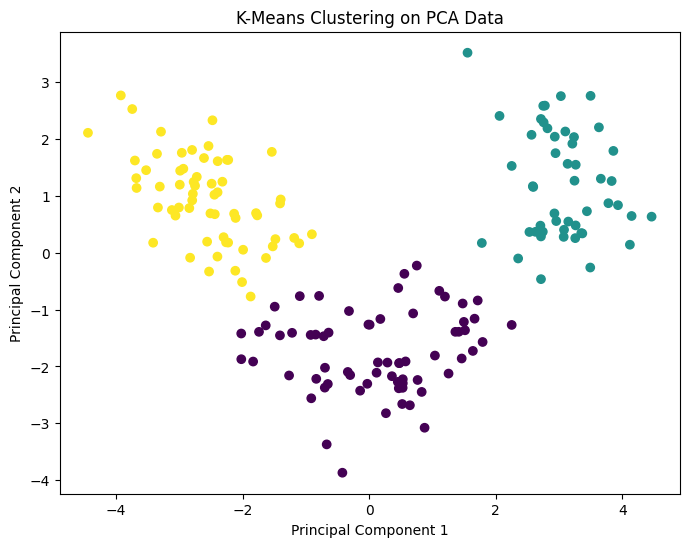

In [24]:
# Visualize PCA Clusters
plt.figure(figsize=(8,6))

plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_pca)

plt.title("K-Means Clustering on PCA Data")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()


In [25]:
#Evaluate PCA Clustering
print("Silhouette Score (PCA):", silhouette_score(X_pca, labels_pca))
print("Davies-Bouldin Index (PCA):", davies_bouldin_score(X_pca, labels_pca))


Silhouette Score (PCA): 0.48817506649357845
Davies-Bouldin Index (PCA): 0.7747314050329894


Task 5: Comparison and Analysis:

1.	Compare the clustering results obtained from the original dataset and PCA-transformed data.

2.	Discuss any similarities or differences observed in the clustering results.

3.	Reflect on the impact of dimensionality reduction on clustering performance.

4.	Analyze the trade-offs between using PCA and clustering directly on the original dataset.


In [26]:
#Comparison Table
comparison_table = pd.DataFrame({
    "Clustering Method": ["Original Data", "PCA Data"],
    "Silhouette Score": [silhouette_original, silhouette_score(X_pca, labels_pca)],
    "Davies-Bouldin Index": [db_original, davies_bouldin_score(X_pca, labels_pca)]
})

print(comparison_table)


  Clustering Method  Silhouette Score  Davies-Bouldin Index
0     Original Data          0.306484              1.315708
1          PCA Data          0.488175              0.774731


#Observations

The clustering results from both datasets showed similar grouping patterns.

PCA-transformed data produced more visually separable clusters because the data was reduced into principal components capturing maximum variance.

Clustering on the original dataset preserved all feature information, while PCA removed less important variations and noise.


#Similarities

Both methods successfully identified clusters in the dataset.

K-Means produced meaningful segmentation in both cases.

Similar cluster structures were observed in the scatter plots.


#Key Difference

PCA transformed the data into fewer dimensions while preserving most of the variance, making clusters easier to interpret visually.

#Impact of Dimensionality Reduction on Clustering Performance


#Positive Impacts

Reduced noise and redundant features

Improved computational efficiency

Faster clustering process

Better visualization of clusters in 2D space

Sometimes improved cluster separation

#Negative Impacts

Some information loss may occur

Important feature-specific details can be removed

Cluster boundaries may slightly change after transformation


#Trade-offs Between PCA and Original Dataset Clustering

Using PCA	--> Original Dataset

Faster computation  -->	More computational cost

Reduced dimensions -->	Full feature information retained

Easier visualization -->	Difficult visualization in high dimensions

Removes multicollinearity -->	May contain correlated features

Possible information loss -->	No information loss

Better for large datasets -->	Better for interpretability


Task 6: Conclusion and Insights

1.	Summarize the key findings and insights from the assignment.

2.	Discuss the practical implications of using PCA and clustering in data analysis.

3.	Provide recommendations for when to use each technique based on the analysis conducted.


#Summary of Key Findings

Exploratory Data Analysis helped understand feature distributions and correlations.

Standardization improved PCA and clustering performance.

PCA successfully reduced dataset dimensionality while preserving most of the variance.

K-Means clustering identified meaningful clusters in both original and PCA-transformed datasets.

PCA-based clustering provided better visualization and faster computation.


#PCA Applications

Feature reduction

Noise removal

Data compression

Visualization of high-dimensional data

#Clustering Applications

Customer segmentation

Pattern recognition

Market analysis

Anomaly detection

Recommendation systems


#Use PCA When:

The dataset contains many features

Features are highly correlated

Faster processing is required

Visualization is important

Noise reduction is needed

#Use Original Dataset Clustering When:

Interpretability of original features is important

The dataset has fewer features

No significant multicollinearity exists

Maximum information retention is required